In [1]:
# Copyright (C) 2024 Richard Stiskalek
# This program is free software; you can redistribute it and/or modify it
# under the terms of the GNU General Public License as published by the
# Free Software Foundation; either version 3 of the License, or (at your
# option) any later version.
#
# This program is distributed in the hope that it will be useful, but
# WITHOUT ANY WARRANTY; without even the implied warranty of
# MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.  See the GNU General
# Public License for more details.
#
# You should have received a copy of the GNU General Public License along
# with this program; if not, write to the Free Software Foundation, Inc.,
# 51 Franklin Street, Fifth Floor, Boston, MA  02110-1301, USA.
from os.path import exists
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
from scipy.interpolate import interp1d
from os.path import join


import sys
sys.path.append("../")

from reconstruction_comparison import *

%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
RA_coma = csiborgtools.hms_to_degrees(12, 59, 48.7)
dec_coma = csiborgtools.dms_to_degrees(27, 58, 50)

rhat = csiborgtools.radec_to_cartesian(np.asarray([1, RA_coma, dec_coma]).reshape(1, 3))

In [6]:
fdir = "/mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/void_SH0ES_calibrated"

profiles = ["exp", "gauss", "mb"]

logZ = []

for profile in profiles:
    # fname = join(fdir, f"samples_IndranilVoidSizeVar_{profile}_CF4_TFR_i_CF4_TFR_notSDSS_w1_mike_zcmb_max_0.065_sample_beta_which_void_size_run_zoom_remove_CF4_outliers.hdf5")
    fname = join(fdir, f"samples_IndranilVoid_{profile}_CF4_TFR_i_CF4_TFR_notSDSS_w1_mike_zcmb_max_0.065_remove_CF4_outliers.hdf5")
    logZ_i = get_gof("logZ_harmonic", fname)
    logZ.append(logZ_i)

    print(f"LogZ {profile}: {logZ_i}")


logZ = np.asarray(logZ)
logZ -= np.min(logZ)

print()
for profile in profiles:
    print(f"LogZ {profile}: {logZ[profiles.index(profile)]}")






LogZ exp: -50222.536580453336
LogZ gauss: -50223.001411266
LogZ mb: -50306.01951582232

LogZ exp: 83.48293536898564
LogZ gauss: 83.01810455632221
LogZ mb: 0.0


In [6]:
fdir = "/mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/void_SH0ES_calibrated"

profiles = ["exp", "gauss", "mb"]

logZ = []

for profile in profiles:
    fname = join(fdir, f"samples_IndranilVoidSizeVar_{profile}_CF4_TFR_i_CF4_TFR_notSDSS_w1_mike_zcmb_max_0.065_which_void_size_run_zoom_remove_CF4_outliers.hdf5")
    logZ_i = get_gof("logZ_harmonic", fname)
    logZ.append(logZ_i)

    print(f"LogZ {profile}: {logZ_i}")


LogZ exp: -50178.228364522285
LogZ gauss: -50160.931229610236
LogZ mb: -50155.49576273516


In [3]:
def get_vrad(fname):
    if "gauss" in fname:
        profile = "gauss"
    elif "exp" in fname:
        profile = "exp"
    elif "mb" in fname:
        profile = "mb"
    else:
        raise ValueError("Unknown profile")
    # fname = f"/mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/void_calibrated/samples_IndranilVoidSizeVar_{profile}_CF4_TFR_i_CF4_TFR_notSDSS_w1_mike_zcmb_max_0.065_which_void_size_run_zoom_remove_CF4_outliers.hdf5"
    # fname = f"/mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/void_calibrated/samples_IndranilVoidSizeVar_{profile}_CF4_TFR_i_CF4_TFR_notSDSS_w1_mike_zcmb_max_0.065_sample_beta_which_void_size_run_zoom_remove_CF4_outliers.hdf5"
    # /mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/void_SH0ES_calibrated/samples_IndranilVoidSizeVar_exp_CF4_TFR_i_CF4_TFR_notSDSS_w1_mike_zcmb_max_0.065_which_void_size_run_zoom_remove_CF4_outliers.hdf5
    # fname = f"/mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/void_calibrated/samples_IndranilVoidSizeVar_{profile}_CF4_TFR_i_CF4_TFR_notSDSS_w1_bayes_zcmb_max_0.05_which_void_size_run_zoom_remove_CF4_outliers.hdf5"

    samples = get_some_samples(fname, ["Vext_cartesian", "void_size", "rLG", "beta"])


    size_grid, rLG_grid, vrad_grid = csiborgtools.flow.load_void_size_variation(profile, "vrad", "zoom")

    void_size_min = size_grid.min()
    void_size_max = size_grid.max()

    


    rgrid_min = 0
    rgrid_max = 400

    rLG_min = rLG_grid.min()
    rLG_max = rLG_grid.max()

    x_grid, y_grid = csiborgtools.flow.select_void_h(None, profile, return_all=True)
    h_void_func = interp1d(x_grid / 100, y_grid, bounds_error=False, fill_value="extrapolate")

    # print("beta mean ", samples["beta"].mean())
    print("size mean ", samples["void_size"].mean())

    r2zcosmo = csiborgtools.flow.ComovingDistance2Redshift(0.3,)
    r = np.linspace(0, 150, 100)

    vrad = []
    for n in range(500):
        try:
            void_size = samples["void_size"][n]
        except KeyError:
            void_size = 1.
        rLG = samples["rLG"][n]
        Vext = samples["Vext"][n]
        try:
            beta = samples["beta"][n]
        except KeyError:
            beta = 1.0
        h_void = h_void_func(void_size)

        Vext_rad = np.sum(Vext * rhat[0])

        vrad_ = csiborgtools.flow.interpolate_size_var_void(
            void_size, rLG, h_void, Vext, r, rhat, vrad_grid,
            void_size_min, void_size_max, rgrid_min, rgrid_max, rLG_min, rLG_max,
            )[0]
        vrad.append(beta * vrad_ + Vext_rad)


    vrad = np.asarray(vrad)
    return r, vrad




In [4]:
profile = "mb"
fname = "/mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/void_SH0ES_calibrated/samples_IndranilVoidSizeVar_mb_CF4_TFR_i_CF4_TFR_notSDSS_w1_mike_zcmb_max_0.065_sample_beta_which_void_size_run_zoom_remove_CF4_outliers.hdf5"
# fname = f"/mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/void_calibrated/samples_IndranilVoidSizeVar_{profile}_CF4_TFR_i_CF4_TFR_notSDSS_w1_bayes_zcmb_max_0.05_which_void_size_run_zoom_remove_CF4_outliers.hdf5"

samples = get_some_samples(fname, ["Vext_cartesian", "void_size", "rLG", "beta"])

In [7]:
r, vrad_mb = get_vrad("/mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/void_SH0ES_calibrated/samples_IndranilVoidSizeVar_mb_CF4_TFR_i_CF4_TFR_notSDSS_w1_mike_zcmb_max_0.065_sample_beta_which_void_size_run_zoom_remove_CF4_outliers.hdf5")
r, vrad_gauss = get_vrad("/mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/void_SH0ES_calibrated/samples_IndranilVoidSizeVar_gauss_CF4_TFR_i_CF4_TFR_notSDSS_w1_mike_zcmb_max_0.065_sample_beta_which_void_size_run_zoom_remove_CF4_outliers.hdf5")
r, vrad_exp = get_vrad("/mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/void_SH0ES_calibrated/samples_IndranilVoidSizeVar_exp_CF4_TFR_i_CF4_TFR_notSDSS_w1_mike_zcmb_max_0.065_sample_beta_which_void_size_run_zoom_remove_CF4_outliers.hdf5")
# r, vrad_mb = get_vrad("/mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/void_SH0ES_calibrated/samples_IndranilVoidSizeVar_mb_CF4_TFR_i_CF4_TFR_notSDSS_w1_mike_zcmb_max_0.065_which_void_size_run_zoom_remove_CF4_outliers.hdf5")
# r, vrad_gauss = get_vrad("/mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/void_SH0ES_calibrated/samples_IndranilVoidSizeVar_gauss_CF4_TFR_i_CF4_TFR_notSDSS_w1_mike_zcmb_max_0.065_which_void_size_run_zoom_remove_CF4_outliers.hdf5")
# r, vrad_exp = get_vrad("/mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/void_SH0ES_calibrated/samples_IndranilVoidSizeVar_exp_CF4_TFR_i_CF4_TFR_notSDSS_w1_mike_zcmb_max_0.065_which_void_size_run_zoom_remove_CF4_outliers.hdf5")

2025-04-17 15:05:09,032 loading pre-processed data from `/mnt/extraspace/rstiskalek/catalogs/IndranilVoid/SizeVariation_newDecember/processed_mb_vrad.hdf5`.
size mean  0.14965601
2025-04-17 15:05:18,204 loading pre-processed data from `/mnt/extraspace/rstiskalek/catalogs/IndranilVoid/SizeVariation_newDecember/processed_gauss_vrad.hdf5`.
size mean  0.059661567
2025-04-17 15:05:27,018 loading pre-processed data from `/mnt/extraspace/rstiskalek/catalogs/IndranilVoid/SizeVariation_newDecember/processed_exp_vrad.hdf5`.
size mean  0.06720054


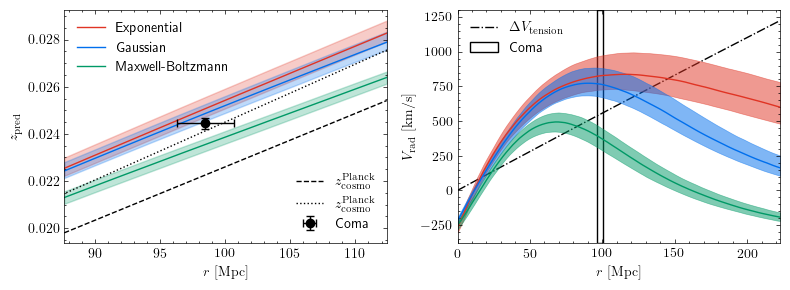

In [21]:
SPEED_OF_LIGHT = 299_792.458  # km/s

# Cosmological conversion
r2zcosmo = csiborgtools.flow.ComovingDistance2Redshift(0.3)
zcosmo = r2zcosmo(r)

# Cluster properties
h_void_here = 0.6740
r_coma = 98.5       # Mpc
e_r_coma = 2.2      # Mpc
zcoma = 0.02445
e_zcoma = 0.00024

r_shoes = r / 0.7304


# Select physical radial range
r_phys = r / h_void_here
rmask = np.abs(r_phys - r_coma) < 15
r_fixed = r_phys[rmask]

vrads = [vrad_exp, vrad_gauss, vrad_mb]
labels = ["Exponential", "Gaussian", "Maxwell-Boltzmann"]
# vrads = [vrad_mb]
# labels = ["Maxwell-Boltzmann"]
# cols = ["#d62728", "#1f77b4", "gray"]
cols = ['#E03424', '#006FED', '#009966']

# --- Begin subplot setup ---
with plt.style.context("science"):
    fig, axs = plt.subplots(1, 2, figsize=(8, 3), sharey=False)

    # ---- Left Plot: r vs z_pred (switched axes) ----
    ymeds, ylows, yhighs = [], [], []
    for vrad in vrads:
        zpred = (1 + zcosmo[None, :]) * (1 + vrad / SPEED_OF_LIGHT) - 1
        ylow, ymed, yhigh = np.percentile(zpred, [16, 50, 84], axis=0)

        ym = ymed[rmask]
        yl = ylow[rmask]
        yh = yhigh[rmask]

        ymeds.append(ym)
        ylows.append(yl)
        yhighs.append(yh)

    ymeds = np.array(ymeds)
    ylows = np.array(ylows)
    yhighs = np.array(yhighs)

    zmask = np.any(np.abs(ymeds - zcoma) < 10 * e_zcoma, axis=0)

    for i, (ym, yl, yh, label) in enumerate(zip(ymeds, ylows, yhighs, labels)):

        axs[0].plot(r_fixed[zmask], ym[zmask], label=label, color=cols[i])
        axs[0].fill_between(r_fixed[zmask], yl[zmask], yh[zmask], alpha=0.25, color=cols[i])

    axs[0].plot(r_fixed[zmask], zcosmo[rmask][zmask], c="k", ls="dashed", label=r"$z_{\rm cosmo}^{\rm Planck}$") 

    axs[0].errorbar(r_coma, zcoma, xerr=e_r_coma, yerr=e_zcoma,
                    fmt="o", color="k", label="Coma", capsize=3)
    axs[0].set_xlabel(r"$r ~ [\mathrm{Mpc}]$")
    axs[0].set_ylabel(r"$z_{\rm pred}$")
    axs[0].set_xlim(r_fixed[zmask].min(), r_fixed[zmask].max())
    # axs[0].legend(ncols=2, columnspacing=0.75, loc="upper left")

    # ---- Right Plot: v_rad profile vs r ----
    for i, (vrad, label) in enumerate(zip(vrads, labels)):
        ylow, ymed, yhigh = np.percentile(vrad, [16, 50, 84], axis=0)
        axs[1].plot(r / h_void_here, ymed, color=cols[i])
        axs[1].fill_between(r / h_void_here, ylow, yhigh, alpha=0.5, color=cols[i], linewidth=0.5)
    
    
    r2zcosmo_planck = csiborgtools.flow.ComovingDistance2Redshift(0.3, 67.4)
    r2zcosmo_shoes = csiborgtools.flow.ComovingDistance2Redshift(0.3, 73.04)
    dV = ((1 + r2zcosmo_shoes(r_phys)) / (1 + r2zcosmo_planck(r_phys)) - 1) * SPEED_OF_LIGHT
    axs[1].plot(r_phys, dV, c="k", ls="dashdot", label=r"$\Delta V_{\rm tension}$", zorder=-1)
    
    axs[1].set_xlabel(r"$r ~ [\mathrm{Mpc}]$")
    axs[1].set_ylabel(r"$V_{\rm rad} ~ [\mathrm{km} / \mathrm{s}]$")
    axs[1].set_xlim(r.min() / h_void_here, r.max() / h_void_here)

    xlim, ylim = axs[0].get_xlim(), axs[0].get_ylim()
    axs[0].plot(r_shoes, zcosmo, c="k", ls="dotted", label=r"$z_{\rm cosmo}^{\rm Planck}$") 
    axs[0].set_xlim(xlim)
    axs[0].set_ylim(ylim)

    # Add vertical bars for coma
    ylim = axs[1].get_ylim()
    axs[1].fill_betweenx(
        ylim,
        r_coma - e_r_coma,
        r_coma + e_r_coma,
        facecolor='none',
        edgecolor='k',
        label="Coma",
        zorder=-1
        )

    axs[1].set_ylim(*ylim)
    axs[1].legend(loc="upper left")

    # Get all handles and labels from axs[1]
    handles, labels = axs[0].get_legend_handles_labels()

    # Split into profiles and bounds
    profile_mask = ["Coma" not in lbl and "z_" not in lbl for lbl in labels]
    bound_mask = ["Coma" in lbl or "z_" in lbl for lbl in labels]

    # First legend (profiles) on axs[0]
    legend1 = axs[0].legend(
        [h for h, m in zip(handles, profile_mask) if m],
        [l for l, m in zip(labels, profile_mask) if m],
        loc="upper left",
        frameon=False
    )
    axs[0].add_artist(legend1)

    # Second legend (bounds) also on axs[0]
    legend2 = axs[0].legend(
        [h for h, m in zip(handles, bound_mask) if m],
        [l for l, m in zip(labels, bound_mask) if m],
        loc="lower right",
        frameon=False
    )

    fig.tight_layout()
    fig.savefig("coma_distance.pdf", dpi=450)
    fig.show()



Array([   0.      ,   12.687007,   25.338276,   37.989544,   50.67655 ,
         63.32782 ,   75.97909 ,   88.55888 ,  101.21015 ,  113.78994 ,
        126.47695 ,  139.05675 ,  151.63654 ,  164.25206 ,  176.8676  ,
        189.44739 ,  201.99144 ,  214.57123 ,  227.1153  ,  239.65935 ,
        252.23914 ,  264.74747 ,  277.32724 ,  289.83557 ,  302.3796  ,
        314.8522  ,  327.39624 ,  339.90457 ,  352.41287 ,  364.88547 ,
        377.35803 ,  389.83063 ,  402.3032  ,  414.7758  ,  427.24835 ,
        439.68518 ,  452.15778 ,  464.55887 ,  477.03146 ,  489.43256 ,
        501.8694  ,  514.2705  ,  526.70734 ,  539.10846 ,  551.4738  ,
        563.87494 ,  576.2403  ,  588.6771  ,  601.0067  ,  613.40784 ,
        625.7375  ,  638.0671  ,  650.4682  ,  662.7621  ,  675.12744 ,
        687.4571  ,  699.7867  ,  712.08057 ,  724.4102  ,  736.7041  ,
        749.03375 ,  761.32764 ,  773.58575 ,  785.87964 ,  798.1735  ,
        810.4317  ,  822.6898  ,  834.948   ,  847.2062  ,  859.

In [13]:
r2zcosmo_planck(100)

Array(0.02259766, dtype=float32)

In [14]:
r2zcosmo_shoes(100)

Array(0.02449927, dtype=float32)

In [ ]:
zc =  ±

(3, 13)

In [25]:
csiborgtools.heliocentric_to_cmb(0.023333, RA_coma, dec_coma, 0.000130)

(0.024245693981066907, 0.00013011594487575274)

In [15]:
from astropy.cosmology import FlatLambdaCDM
from scipy.interpolate import interp1d
cosmo = FlatLambdaCDM(H0=67.4, Om0=0.306)

In [16]:
x = np.linspace(0, 0.05, 100000)
y = cosmo.comoving_distance(x).value

f = interp1d(y, x, bounds_error=False, fill_value="extrapolate")

In [17]:
zcosmo = f(98.5)

In [18]:
(1 + zcosmo) * (1 + 900 / SPEED_OF_LIGHT) - 1

0.025328109410263533

In [20]:
((1 + zcoma) / (1 + zcosmo) - 1) * SPEED_OF_LIGHT

642.4815778073929